## **Load data and setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# display settings
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns = df.columns.str.lower()

In [26]:
# Basic info
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [27]:
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")

## **Missing & data quality**

In [29]:
print(f"Duplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 0


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [31]:
n = len(df)

# Missing count + rate
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_rate": df.isnull().mean()  
})

missing_df = missing_df.sort_values(by="missing_rate", ascending=False)

missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_rate
totalcharges,11,0.001562


In [38]:
# Fill missing value by 0

df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")
df["totalcharges"] = df["totalcharges"].fillna(0)

In [39]:
df.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [43]:
df_eda = df.copy()

## **Target Distribution**

In [40]:
df["churn"].value_counts(normalize=True)

churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## **Univariate analysis**

### Numeric

In [41]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges'], dtype='str')

In [48]:
num_cols = num_cols.drop("seniorcitizen")

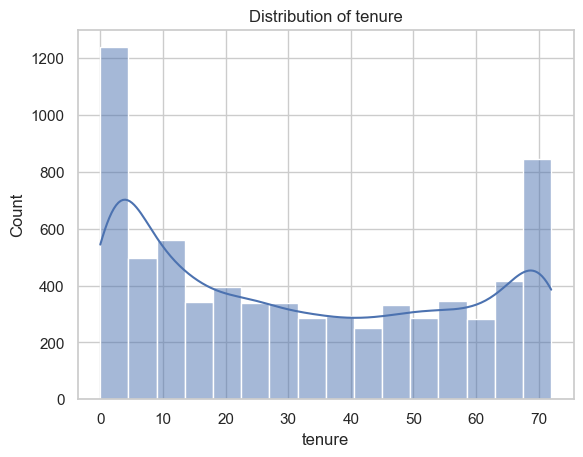

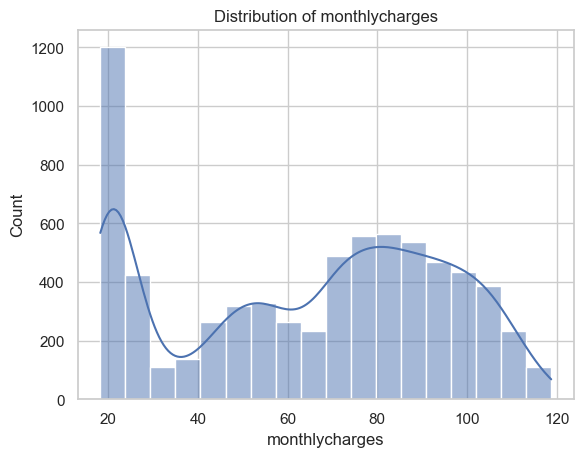

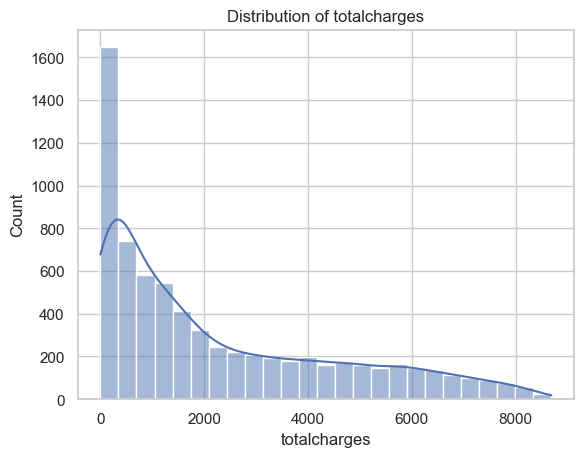

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

**tenure**:   
- Peak at 0–10 months → new users  
- Peak at ~70 months → loyal users  
- 20–50 months: relatively flat → fewer mid-term users  
→ New users are more likely to churn, while long-term users are more stable  
→ Non-linear relationship → logistic regression may be less effective  

**monthlycharges**:  
- Two clusters: 20–30 (low-cost) and 70–100 (high-cost)
→ Indicates two customer segments: cheap plan vs premium plan
→ Likely different churn behaviors between these groups

**totalcharges**:  
- Right-skewed with a peak at low values → many new users  
- Long tail → long-term users with high accumulated charges
→ Reflects cumulative spending (linked to tenure)  
→ Not independent, non-linear, and potentially redundant  

### Categorical

In [60]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

C:\Users\Thu Hang\AppData\Local\Temp\ipykernel_21984\2960911289.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod', 'churn'],
      dtype='str')

In [71]:
cat_cols = cat_cols.drop(["customerid"])

In [72]:
for col in cat_cols:
    print(df[col].value_counts(normalize=True))

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64
partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64
dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64
phoneservice
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64
multiplelines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64
internetservice
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64
onlinesecurity
No                     0.496663
Yes                    0.286668
No internet service    0.216669
Name: proportion, dtype: float64
onlinebackup
No                     0.438450
Yes                    0.344881
No internet service    0.216669
Name: proportion, dtype: float64
deviceprotection
No                     0.439443
Yes                    0.343888
No internet service    0.216669
Name: proportion, dtype: float64
techsupp

## **Relationship vs Churn**

### Numeric

In [69]:
num_cols

Index(['tenure', 'monthlycharges', 'totalcharges'], dtype='str')

In [70]:
df.groupby("churn")[["tenure","monthlycharges","totalcharges"]].mean()

,tenure,monthlycharges,totalcharges
churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


<Axes: >

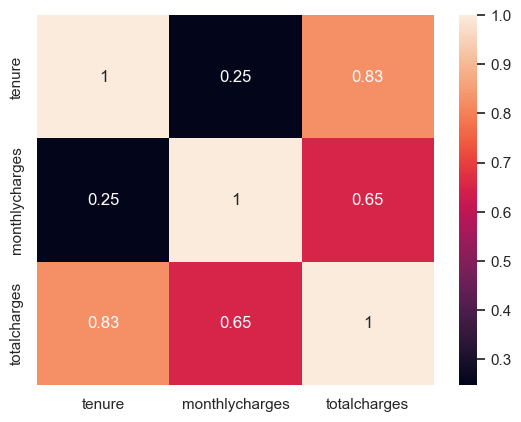

In [58]:
sns.heatmap(df[num_cols].corr(), annot=True)

## Categorical

In [56]:
for col in cat_cols:
    print("\n", col)
    print(pd.crosstab(df[col], df["churn"], normalize="index"))


 gender
churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603

 partner
churn          No       Yes
partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649

 dependents
churn             No       Yes
dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502

 phoneservice
churn               No       Yes
phoneservice                    
No            0.750733  0.249267
Yes           0.732904  0.267096

 multiplelines
churn                   No       Yes
multiplelines                       
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099

 internetservice
churn                  No       Yes
internetservice                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050

 onlinesecurity
churn                      No       Yes
onlinesecurity       

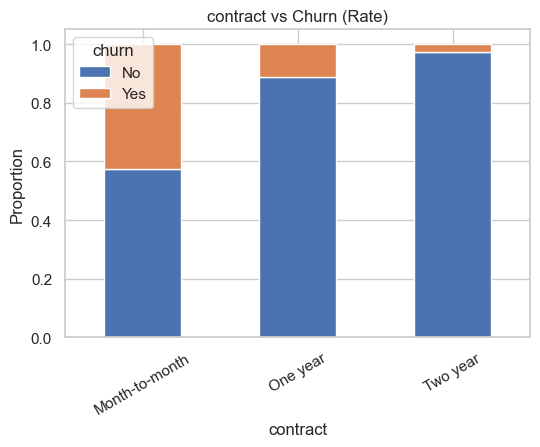

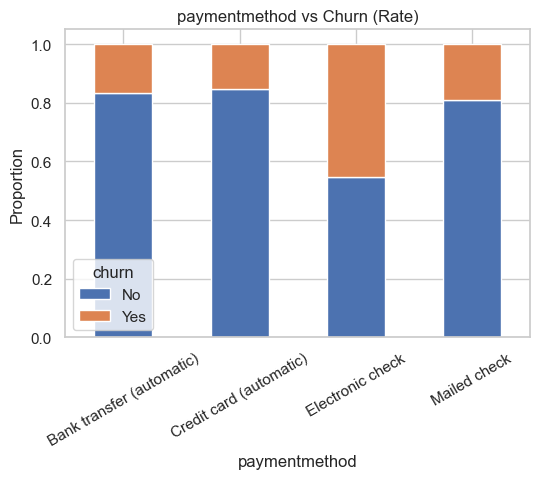

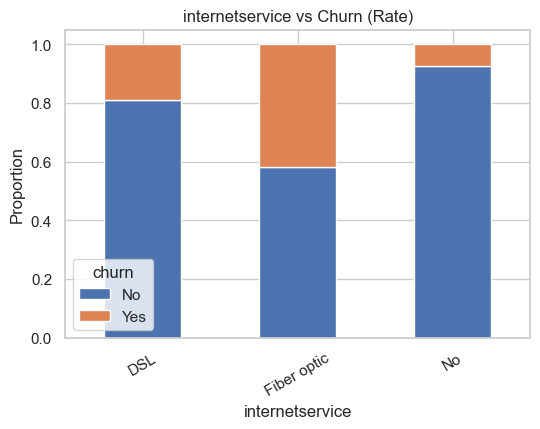

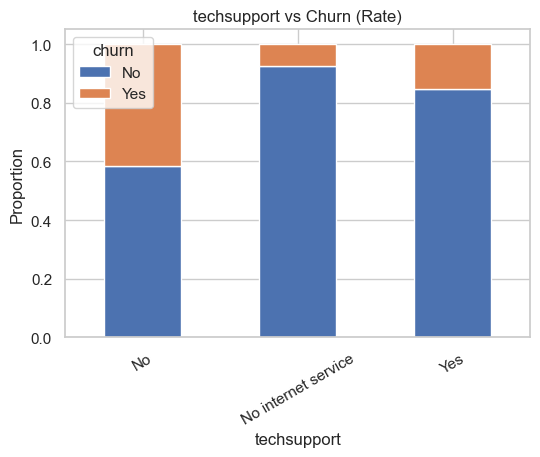

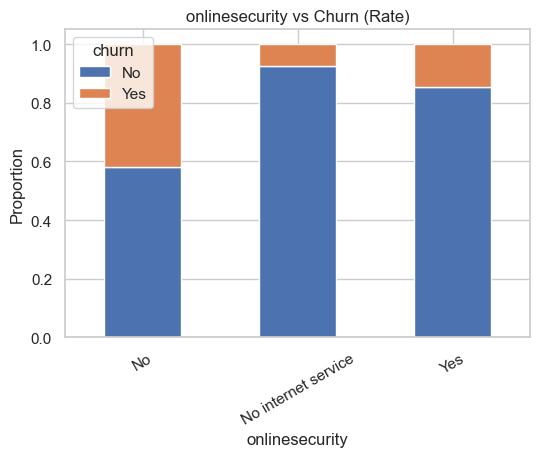

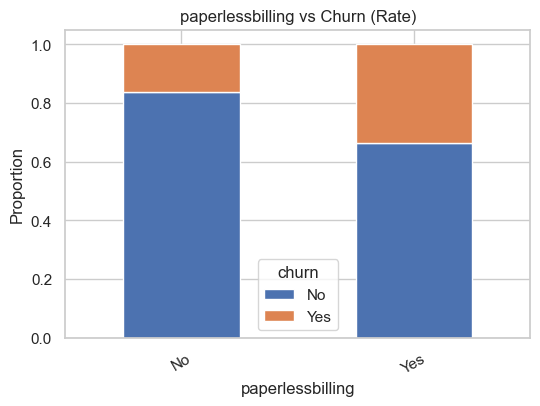

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_plot = [
    "contract",
    "paymentmethod",
    "internetservice",
    "techsupport",
    "onlinesecurity",
    "paperlessbilling"
]

for col in cols_to_plot:
    ct = pd.crosstab(df[col], df["churn"], normalize="index")
    ct.plot(kind="bar", stacked=True, figsize=(6,4))
    plt.title(f"{col} vs Churn (Rate)")
    plt.ylabel("Proportion")
    plt.xticks(rotation=30)
    plt.show()

- **Contract**:  
Month-to-month users have significantly higher churn, while long-term contracts (1–2 years) greatly reduce churn  

- **PaymentMethod:**  
Electronic check users show the highest churn → possible friction or riskier segment  

- **InternetService**:  
Fiber optic users churn more than DSL → higher expectations or pricing impact  

- **TechSupport & OnlineSecurity**:
Users without these services churn much more → service quality strongly affects retention  

- **PaperlessBilling**:
Paperless users have higher churn → possibly linked to payment behavior or user type

## **Feature Importance (Baseline Model)**

This section trains a simple baseline model to estimate which features contribute most to churn prediction.
We use one-hot encoding for categorical variables and RandomForest feature importances for interpretation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Prepare features and target
y = df["churn"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})
if y.isna().any():
    unknown_labels = sorted(df.loc[y.isna(), "churn"].astype(str).unique().tolist())
    raise ValueError(f"Unexpected churn labels found: {unknown_labels}")

X = df.drop(columns=["churn", "customerid"], errors="ignore").copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Build preprocessing + model pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

pipeline.fit(X_train, y_train)
y_proba = pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"Baseline RandomForest ROC-AUC: {auc:.4f}")

# Encoded feature importance
fitted_preprocessor = pipeline.named_steps["preprocessor"]
fitted_model = pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

importance_encoded = pd.DataFrame(
    {
        "encoded_feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

# Aggregate importance back to original feature names
base_columns = X.columns.tolist()

def map_to_original_feature(encoded_name: str, candidates: list[str]) -> str:
    for col in candidates:
        if encoded_name == f"num__{col}":
            return col
        if encoded_name.startswith(f"cat__{col}_"):
            return col
    return encoded_name

importance_encoded["original_feature"] = importance_encoded["encoded_feature"].apply(
    lambda name: map_to_original_feature(name, base_columns)
)

importance_by_original = (
    importance_encoded.groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("\nTop encoded features:")
display(importance_encoded.head(20))

print("Top original features:")
display(importance_by_original.head(15))

# Plot top original features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_by_original.head(12),
    x="importance",
    y="original_feature",
    palette="viridis",
)
plt.title("Top 12 Original Features by RandomForest Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()